In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q tensorflow matplotlib seaborn scikit-learn opencv-python

# AI-Generated Image Detection Using CNN with Grad-CAM

## PROGRAM

### 1. Import Required Libraries

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

print("Setup complete.")

Setup complete.


### 2. Load Dataset

In [4]:
# Download the CIFAKE dataset

!git clone -q https://github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images.git

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [5]:
import os

dataset_path = "/content/CIFAKE-Real-and-AI-Generated-Synthetic-Images/DATASET"

print("Dataset path:", dataset_path)
print("\nContents:")

for item in os.listdir(dataset_path):
    print(item)

Dataset path: /content/CIFAKE-Real-and-AI-Generated-Synthetic-Images/DATASET

Contents:
train
test


In [6]:
# Check dataset class distribution

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

for split, split_path in [("Training", train_path), ("Testing", test_path)]:
    print(f"\n{split} Dataset:")

    for class_name in ["REAL", "FAKE"]:
        class_path = os.path.join(split_path, class_name)
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        print(f"{class_name}: {count} images")


Training Dataset:
REAL: 50000 images
FAKE: 50000 images

Testing Dataset:
REAL: 10000 images
FAKE: 10000 images


### 3. Display Dataset Information

In [7]:
# Display dataset information

print("Training Dataset:")
print("REAL images:", len(os.listdir(os.path.join(train_path, "REAL"))))
print("FAKE images:", len(os.listdir(os.path.join(train_path, "FAKE"))))

print("\nTesting Dataset:")
print("REAL images:", len(os.listdir(os.path.join(test_path, "REAL"))))
print("FAKE images:", len(os.listdir(os.path.join(test_path, "FAKE"))))

print("\nTotal Images:",
      len(os.listdir(os.path.join(train_path, "REAL"))) +
      len(os.listdir(os.path.join(train_path, "FAKE"))) +
      len(os.listdir(os.path.join(test_path, "REAL"))) +
      len(os.listdir(os.path.join(test_path, "FAKE"))))

Training Dataset:
REAL images: 50000
FAKE images: 50000

Testing Dataset:
REAL images: 10000
FAKE images: 10000

Total Images: 120000


### 4. Display Sample Images

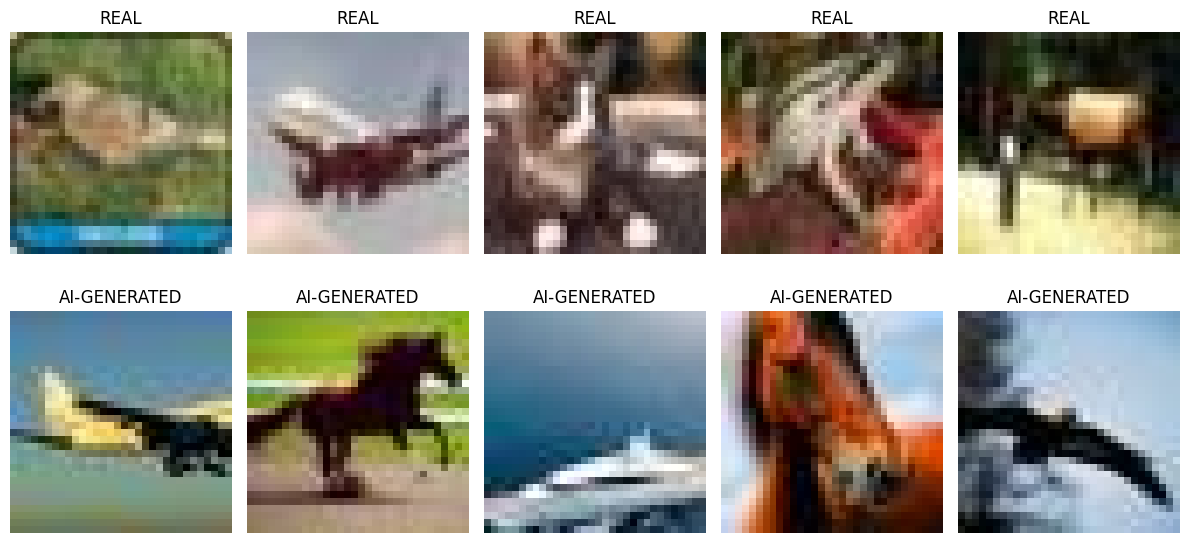

In [8]:
# Display sample REAL and AI-generated images

import random
from PIL import Image

plt.figure(figsize=(12, 6))

# Display REAL images
for i in range(5):
    image_name = random.choice(os.listdir(os.path.join(train_path, "REAL")))
    image_path = os.path.join(train_path, "REAL", image_name)

    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title("REAL")
    plt.axis("off")

# Display FAKE images
for i in range(5):
    image_name = random.choice(os.listdir(os.path.join(train_path, "FAKE")))
    image_path = os.path.join(train_path, "FAKE", image_name)

    image = Image.open(image_path)

    plt.subplot(2, 5, i + 6)
    plt.imshow(image)
    plt.title("AI-GENERATED")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 5. Visualize Dataset Distribution

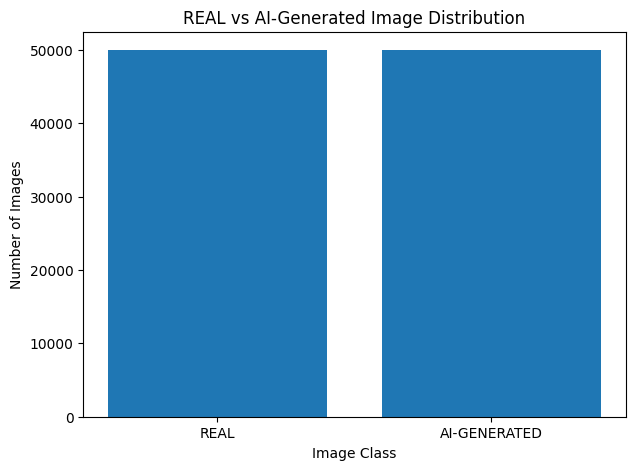

In [9]:
# Visualize REAL vs AI-generated image distribution

labels = ["REAL", "AI-GENERATED"]
counts = [
    len(os.listdir(os.path.join(train_path, "REAL"))),
    len(os.listdir(os.path.join(train_path, "FAKE")))
]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)
plt.xlabel("Image Class")
plt.ylabel("Number of Images")
plt.title("REAL vs AI-Generated Image Distribution")
plt.show()

### 6. Image Preprocessing

In [10]:
# Image preprocessing and data pipeline

IMG_SIZE = (32, 32)
BATCH_SIZE = 64
SEED = 42

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    class_names=["FAKE", "REAL"]
)

# Create validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    class_names=["FAKE", "REAL"]
)

# Create test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_names=["FAKE", "REAL"]
)

print("\nClass names:", ["FAKE", "REAL"])
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Found 100000 files belonging to 2 classes.
Using 90000 files for training.
Found 100000 files belonging to 2 classes.
Using 10000 files for validation.
Found 20000 files belonging to 2 classes.

Class names: ['FAKE', 'REAL']
Image size: (32, 32)
Batch size: 64


In [11]:
# Optimize the input pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Data pipeline ready.")

Data pipeline ready.


### 7. Verify Preprocessed Data

In [12]:
# Check one batch of images and labels

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel value range:", images.numpy().min(), "to", images.numpy().max())

Image batch shape: (64, 32, 32, 3)
Label batch shape: (64, 1)
Pixel value range: 0.0 to 255.0


### 8. Build Convolutional Neural Network (CNN)

In [13]:
# Build the CNN model

model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    # Data normalization
    tf.keras.layers.Rescaling(1./255),

    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Final convolution layer - used for Grad-CAM
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        name="last_conv"
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification layers
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    # Binary classification output
    tf.keras.layers.Dense(1, activation="sigmoid")
])

print("CNN model created successfully!")

CNN model created successfully!


### 9. Display CNN Model Architecture

In [14]:
# Display model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

### 10. Compile CNN Model

In [15]:
# Compile the CNN model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


### 11. Train the CNN Model

In [16]:
# Train the CNN model

EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8423 - loss: 0.3528 - val_accuracy: 0.9096 - val_loss: 0.2292
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9113 - loss: 0.2235 - val_accuracy: 0.9286 - val_loss: 0.1843
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9252 - loss: 0.1916 - val_accuracy: 0.9310 - val_loss: 0.1764
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9326 - loss: 0.1741 - val_accuracy: 0.9357 - val_loss: 0.1668
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9382 - loss: 0.1602 - val_accuracy: 0.9442 - val_loss: 0.1452


### 12. Visualize Training Accuracy and Loss

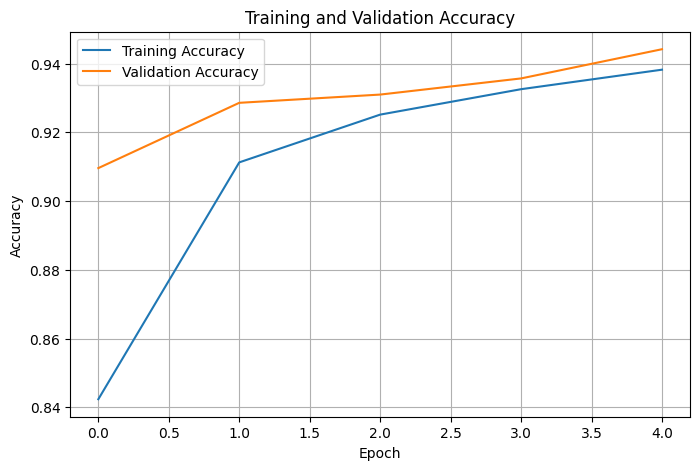

In [17]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

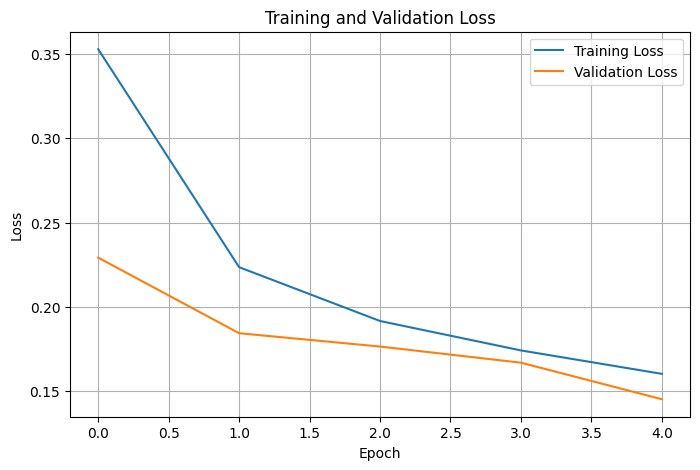

In [18]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### 13. Evaluate CNN Model

In [19]:
# Evaluate the model on the unseen test dataset

test_loss, test_accuracy = model.evaluate(test_ds)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9424 - loss: 0.1477

Test Loss: 0.14770972728729248
Test Accuracy: 0.9423999786376953
Test Accuracy (%): 94.23999786376953


### 14. Generate Predictions

In [20]:
# Generate predictions for the test dataset

y_true = []
y_pred_prob = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert probabilities to class labels
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Total test images:", len(y_true))
print("Predictions generated successfully!")

Total test images: 20000
Predictions generated successfully!


### 15. Classification Report

In [21]:
# Display classification report

print(classification_report(
    y_true,
    y_pred,
    target_names=["AI-GENERATED", "REAL"]
))

              precision    recall  f1-score   support

AI-GENERATED       0.94      0.95      0.94     10000
        REAL       0.95      0.94      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



### 16. Confusion Matrix

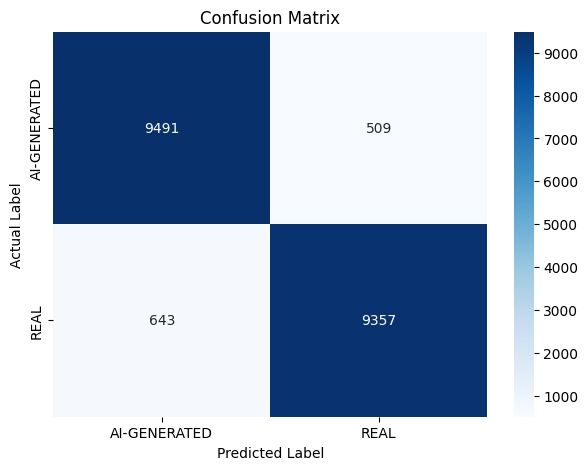

In [22]:
# Create confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["AI-GENERATED", "REAL"],
    yticklabels=["AI-GENERATED", "REAL"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

### 17. ROC Curve

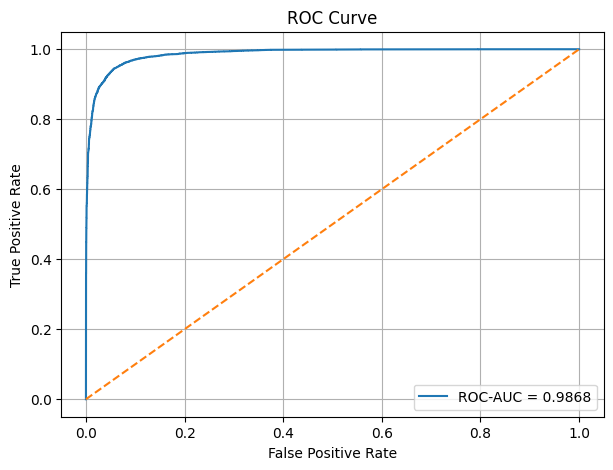

ROC-AUC Score: 0.9867802649999999


In [23]:
# Plot ROC curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

print("ROC-AUC Score:", roc_auc)

### 18. Grad-CAM Explainability

In [24]:
# Grad-CAM function - compatible with Sequential CNN

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    target_layer = model.get_layer(last_conv_layer_name)

    with tf.GradientTape() as tape:

        x = tf.cast(img_array, tf.float32)

        # Forward pass through the model layer by layer
        for layer in model.layers:

            x = layer(x)

            # Save output of the target convolution layer
            if layer.name == last_conv_layer_name:
                conv_outputs = x

        predictions = x

        # Score for AI-generated class
        loss = predictions[:, 0]

    # Gradients of prediction with respect to convolution output
    grads = tape.gradient(loss, conv_outputs)

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :],
        axis=-1
    )

    # Keep positive values
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()


print("Grad-CAM function ready.")

Grad-CAM function ready.


### 19. Select Test Image for Grad-CAM

In [25]:
# Select one REAL and one AI-generated test image

real_files = [
    f for f in os.listdir(os.path.join(test_path, "REAL"))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

fake_files = [
    f for f in os.listdir(os.path.join(test_path, "FAKE"))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

real_image_path = os.path.join(
    test_path, "REAL", random.choice(real_files)
)

fake_image_path = os.path.join(
    test_path, "FAKE", random.choice(fake_files)
)

print("REAL image:", real_image_path)
print("AI-generated image:", fake_image_path)

REAL image: /content/CIFAKE-Real-and-AI-Generated-Synthetic-Images/DATASET/test/REAL/0945 (4).jpg
AI-generated image: /content/CIFAKE-Real-and-AI-Generated-Synthetic-Images/DATASET/test/FAKE/1 (2).jpg


In [26]:
# Initialize the model for Grad-CAM

_ = model(tf.zeros((1, 32, 32, 3)))

print("Model initialized for Grad-CAM.")

Model initialized for Grad-CAM.


### 20. Grad-CAM for AI-Generated Image



In [27]:
# Generate Grad-CAM for an AI-generated image

img = tf.keras.utils.load_img(
    fake_image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)
input_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(input_array, verbose=0)[0][0]

predicted_class = "REAL" if prediction >= 0.5 else "AI-GENERATED"
confidence = prediction if prediction >= 0.5 else 1 - prediction

# Generate heatmap
heatmap = make_gradcam_heatmap(
    input_array,
    model,
    "last_conv"
)

print("Actual Class: AI-GENERATED")
print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

Actual Class: AI-GENERATED
Predicted Class: AI-GENERATED
Confidence: 99.09%


### 21. Visualize Grad-CAM for AI-Generated Image

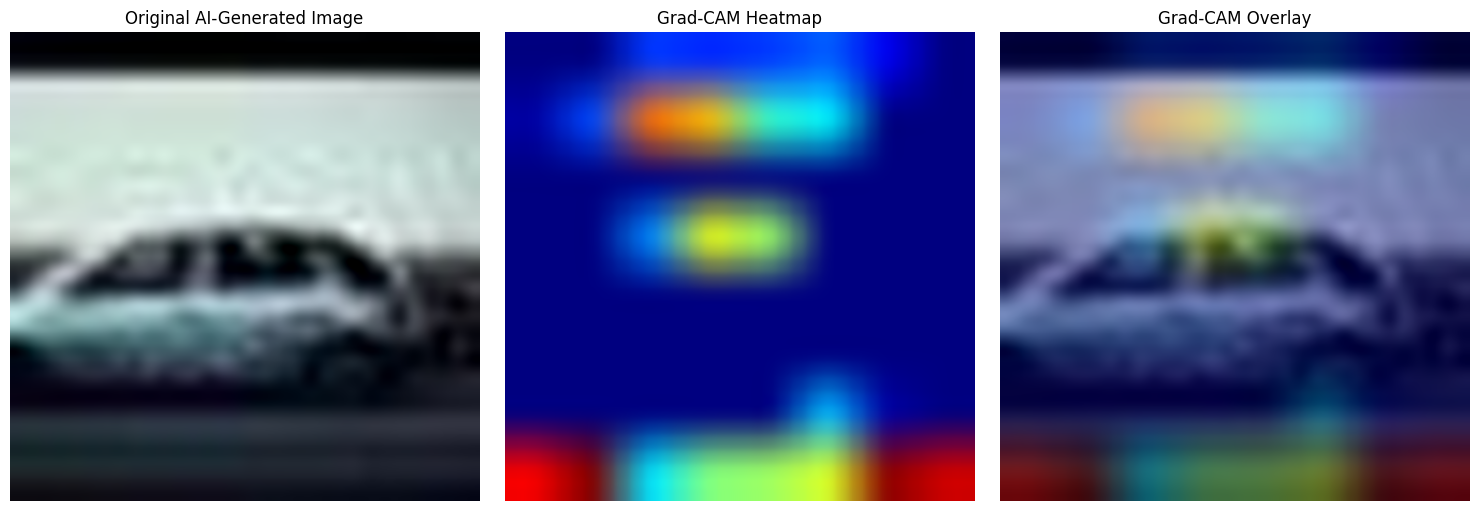

In [28]:
# 21. Visualize Grad-CAM

import cv2
import matplotlib.pyplot as plt

# Convert heatmap to 0-255
heatmap_uint8 = np.uint8(255 * heatmap)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert original image to RGB
original_image = np.array(img).astype(np.uint8)

# Resize heatmap to original image size
heatmap_color = cv2.resize(
    heatmap_color,
    (original_image.shape[1], original_image.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Create overlay
overlay = cv2.addWeighted(
    original_image,
    0.6,
    heatmap_color,
    0.4,
    0
)

# --------------------------------------------------
# Upscale images ONLY for better visualization
# Model still uses the original 32x32 image
# --------------------------------------------------

DISPLAY_SIZE = 512

original_display = cv2.resize(
    original_image,
    (DISPLAY_SIZE, DISPLAY_SIZE),
    interpolation=cv2.INTER_CUBIC
)

heatmap_display = cv2.resize(
    heatmap_color,
    (DISPLAY_SIZE, DISPLAY_SIZE),
    interpolation=cv2.INTER_CUBIC
)

overlay_display = cv2.resize(
    overlay,
    (DISPLAY_SIZE, DISPLAY_SIZE),
    interpolation=cv2.INTER_CUBIC
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_display)
plt.title("Original AI-Generated Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_display)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_display)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

### 22. Save Grad-CAM Visualization

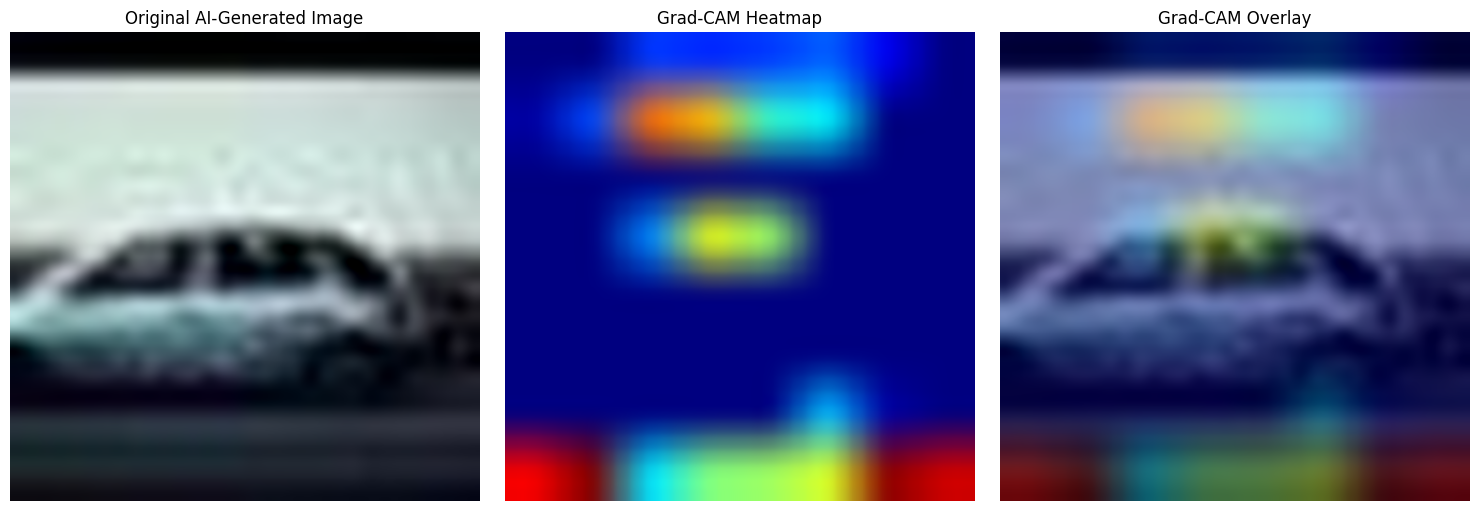

Grad-CAM result saved successfully.


In [29]:
# 22. Save Grad-CAM Visualization

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_display)
plt.title("Original AI-Generated Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_display)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_display)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/gradcam_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Grad-CAM result saved successfully.")

### 23. Grad-CAM for REAL Image

In [30]:
# 23. Grad-CAM for Real Image

# Load real image
real_img = tf.keras.utils.load_img(
    real_image_path,
    target_size=IMG_SIZE
)

real_img_array = tf.keras.utils.img_to_array(real_img)
real_input_array = np.expand_dims(real_img_array, axis=0)

# Prediction
real_prediction = model.predict(
    real_input_array,
    verbose=0
)[0][0]

real_predicted_class = (
    "REAL" if real_prediction >= 0.5 else "AI-GENERATED"
)

real_confidence = (
    real_prediction if real_prediction >= 0.5
    else 1 - real_prediction
)

# Generate Grad-CAM
real_heatmap = make_gradcam_heatmap(
    real_input_array,
    model,
    "last_conv"
)

print("Actual Class: REAL")
print("Predicted Class:", real_predicted_class)
print(f"Confidence: {real_confidence * 100:.2f}%")

Actual Class: REAL
Predicted Class: REAL
Confidence: 100.00%


### 24. Generate Grad-CAM for REAL Image

In [31]:
# 24. Generate Grad-CAM for Real Image

real_heatmap = make_gradcam_heatmap(
    real_input_array,
    model,
    "last_conv"
)

print("Grad-CAM generated successfully for REAL image.")

Grad-CAM generated successfully for REAL image.


### 25. Visualize Grad-CAM for REAL Image

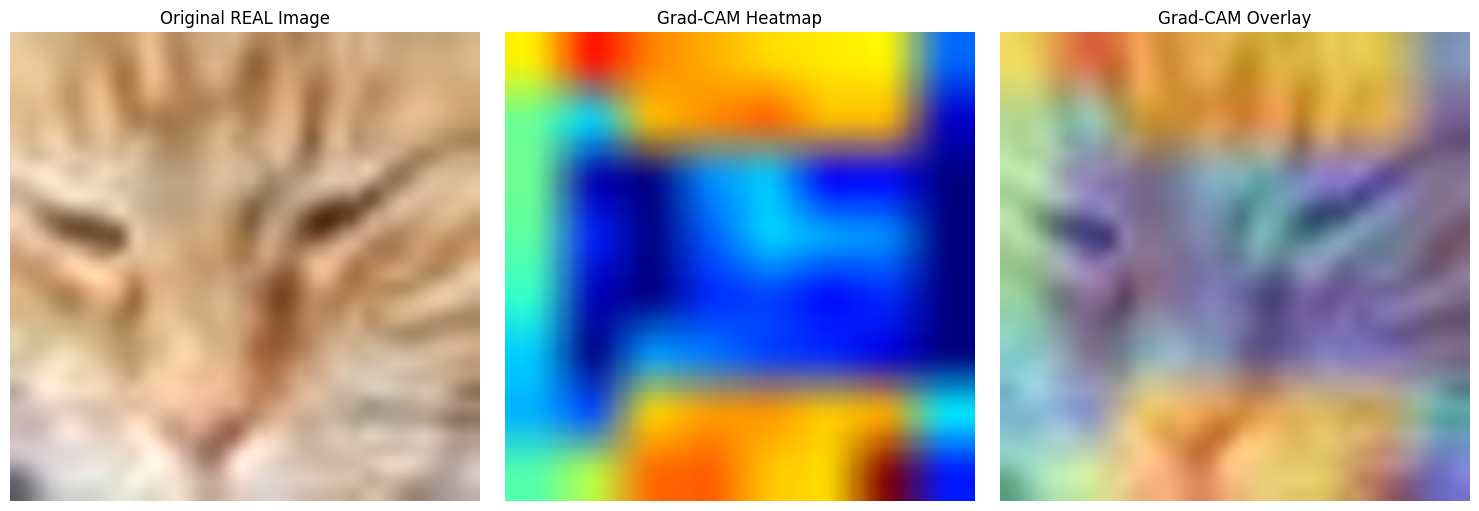

In [32]:
# 25. Visualize Grad-CAM for REAL Image

# Convert heatmap to 0-255
real_heatmap_uint8 = np.uint8(255 * real_heatmap)

# Apply color map
real_heatmap_color = cv2.applyColorMap(
    real_heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert original image to RGB
real_original_image = np.array(real_img).astype(np.uint8)

# Resize heatmap to original image size
real_heatmap_color = cv2.resize(
    real_heatmap_color,
    (real_original_image.shape[1], real_original_image.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

# Convert BGR to RGB
real_heatmap_color = cv2.cvtColor(
    real_heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Create overlay
real_overlay = cv2.addWeighted(
    real_original_image,
    0.6,
    real_heatmap_color,
    0.4,
    0
)

# Upscale ONLY for visualization
DISPLAY_SIZE = 512

real_original_display = cv2.resize(
    real_original_image,
    (DISPLAY_SIZE, DISPLAY_SIZE),
    interpolation=cv2.INTER_CUBIC
)

real_heatmap_display = cv2.resize(
    real_heatmap_color,
    (DISPLAY_SIZE, DISPLAY_SIZE),
    interpolation=cv2.INTER_CUBIC
)

real_overlay_display = cv2.resize(
    real_overlay,
    (DISPLAY_SIZE, DISPLAY_SIZE),
    interpolation=cv2.INTER_CUBIC
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(real_original_display)
plt.title("Original REAL Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(real_heatmap_display)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(real_overlay_display)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

### 26. Custom Image Prediction

Saving ChatGPT Image Sep 21, 2026, 01_06_39 PM.png to ChatGPT Image Sep 21, 2026, 01_06_39 PM.png
Image: ChatGPT Image Sep 21, 2026, 01_06_39 PM.png
Predicted Class: AI-GENERATED
Confidence: 100.00%


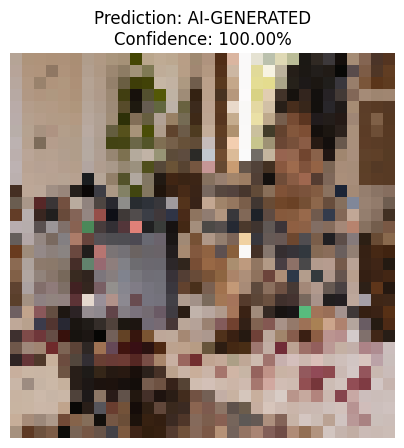

In [33]:
# 26. Predict a custom image

from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():

    custom_img = tf.keras.utils.load_img(
        filename,
        target_size=IMG_SIZE
    )

    custom_img_array = tf.keras.utils.img_to_array(custom_img)
    custom_input = np.expand_dims(custom_img_array, axis=0)

    prediction = model.predict(
        custom_input,
        verbose=0
    )[0][0]

    predicted_class = (
        "REAL" if prediction >= 0.5
        else "AI-GENERATED"
    )

    confidence = (
        prediction if prediction >= 0.5
        else 1 - prediction
    )

    print("Image:", filename)
    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence * 100:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(custom_img)
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.show()

### 26. Final Model Performance

In [34]:
# 26. Final Model Performance

print("========== FINAL MODEL PERFORMANCE ==========")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"ROC-AUC Score : {roc_auc:.4f}")
print("=============================================")

========== FINAL MODEL PERFORMANCE ==========
Test Accuracy : 94.24%
Test Loss     : 0.1477
ROC-AUC Score : 0.9868


### 27. Save Trained CNN Model

In [35]:
# 27. Save the trained model

model.save("/content/AI_Image_Detection_CNN.keras")

print("Model saved successfully!")

Model saved successfully!


### 28. Download Trained Model

In [36]:
# 28. Download the trained model

from google.colab import files

files.download("/content/AI_Image_Detection_CNN.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>